In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


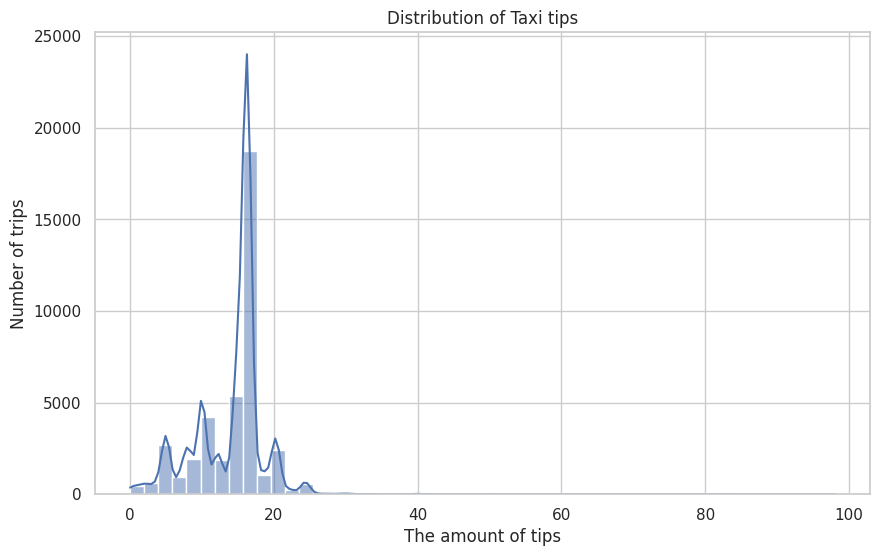

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
taxi.shape
taxi.head()
taxi.info()
taxi.describe()
# - count missing values per column:
taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(10,6))
sns.histplot(data=taxi,x="tip_amount",bins=50,kde=True)
plt.title("Distribution of Taxi tips")
plt.xlabel("The amount of tips")
plt.ylabel("Number of trips")
plt.show()




answers for the above:
What is the shape of the data?
The tip amount distribution is right skewed.

Are there missing values or impossible values (e.g. negative tips, zero-distance trips)?
There are no missing values.

What does the tip_amount distribution look like (skew, outliers, many zeros)?
The tip amount is rightly skewed.

How will this influence your preprocessing?
The mere fact that its skewed shows that preprocessing is needed, to handle the extremes.

In [4]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi=taxi.dropna()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
taxi["fare_per_mile"]=taxi["fare_amount"]/taxi["trip_distance"]
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
taxi["total_surcharges"]=(taxi["mta_tax"]+taxi["tolls_amount"]+taxi["improvement_surcharge"])
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

X=taxi.drop("tip_amount",axis=1)
Y=taxi["tip_amount"]
X=pd.get_dummies(X, drop_first=True)


# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler

 1. How did you handle missing/invalid rows and why?
 I used dropna() to handle missing values,because, missing values are not meaninful here, and would affect the training negatively.

  2. Which new feature(s) did you engineer and what is the intuition behind them?
  The two new features were fare_per_mile and total_surcharges.
  fare_per_mile checks how much a passenger is charged for a mile, and total_surcharges calculates the extra costs for the trip. The intuition behind both is that, they help the models improve in calculating tips.
   3. Which scaling method did you choose and why is it appropriate here?
   I used the standardscaler so that itd have a mean of 0 and a dtandard deviation of 1. This ensures that machine learning models have the same performance level regardless of how big or small the numbers are.



In [8]:
# TODO: Separate features (X) and target (y = tip_amount)
X=taxi.drop("tip_amount",axis=1)
Y=taxi["tip_amount"]
# TODO: Split into train / validation / test (a common choice is 60/20/20).
from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
RANDOM_STATE=42
Xtrain,Xtemp,ytrain,ytemp=train_test_split(X,Y,test_size=0.4,random_state=RANDOM_STATE)
Xval,Xtest,yval,ytest=train_test_split(Xtemp,ytemp,test_size=0.5,random_state=RANDOM_STATE)
# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
import numpy as np

Xtrain = Xtrain.replace([np.inf, -np.inf], np.nan)
Xval = Xval.replace([np.inf, -np.inf], np.nan)
Xtest = Xtest.replace([np.inf, -np.inf], np.nan)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Xtrain = imputer.fit_transform(Xtrain)
Xval = imputer.transform(Xval)
Xtest = imputer.transform(Xtest)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xtrainscaled = scaler.fit_transform(Xtrain)
Xvalscaled = scaler.transform(Xval)
Xtestscaled = scaler.transform(Xtest)

 What ratio did you use?
 60% for training, 20% for validating and 20%for testing.
  Why is a separate validation set useful in addition to a test set?
  The validation set allows us to compare how well the model will work, without touching the test set, and it also helps prevent overfitting of test data, to ensure unbias and fairness

   Why must the scaler (and any imputation statistics) be fit on the training data only?
   It must fit only the training data to ensure the model doesnt memorize information from validation and test set, so it can give a fair evaluation on data it has not seen before.

RMSE FOR TRAINED: 4.91006993790872
RMSE FOR VALIDATED: 4.896622812812118
RMSE FOR TEST: 4.893153456426947
TRAIN R2: 0.050145150454353304
VALIDATED R2: 0.045811167858241686
TEST R2: 0.05184496799919247


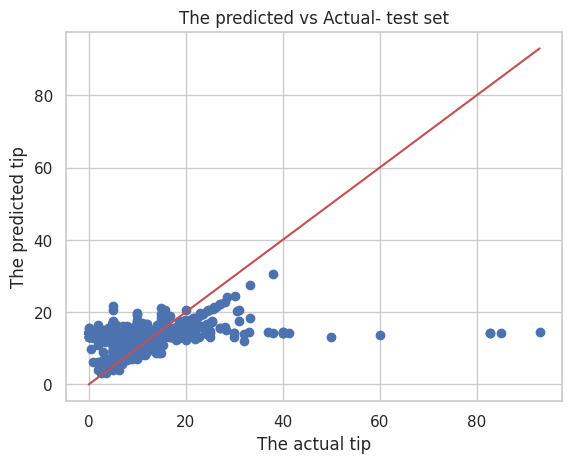

In [10]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# TODO: Predict on train, validation, and test sets.
trainedmodel=LinearRegression()
trainedmodel.fit(Xtrainscaled,ytrain)
predictedytrain=trainedmodel.predict(Xtrainscaled)
predictedyval=trainedmodel.predict(Xvalscaled)
predictedytest=trainedmodel.predict(Xtestscaled)


# TODO: Report RMSE and R^2 for ALL THREE sets.
from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print("RMSE FOR TRAINED:",mean_squared_error(ytrain,predictedytrain)**0.5)
print("RMSE FOR VALIDATED:",mean_squared_error(yval,predictedyval)**0.5)
print("RMSE FOR TEST:",mean_squared_error(ytest,predictedytest)**0.5)

print("TRAIN R2:",r2_score(ytrain,predictedytrain))
print("VALIDATED R2:",r2_score(yval,predictedyval))
print("TEST R2:",r2_score(ytest,predictedytest))

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
import matplotlib.pyplot as plt
plt.scatter(ytest,predictedytest)
plt.plot([ytest.min(),ytest.max()],[ytest.min(),ytest.max()],'r')
plt.xlabel("The actual tip")
plt.ylabel("The predicted tip")
plt.title("The predicted vs Actual- test set")
plt.show()

 1. Which model performed best on the validation set, and which hyper-parameters did you try?
 The random forest model, the hyperparameters were the number of trees and the tree depth.
  2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.
RMSE FOR TRAINED: 4.91006993790872
RMSE FOR VALIDATED: 4.896622812812118
RMSE FOR TEST: 4.893153456426947
TRAIN R2: 0.050145150454353304
VALIDATED R2: 0.045811167858241686
TEST R2: 0.05184496799919247
since the rmse values are very close, theres not much evidence to say the model is underfitting or underfitting. But the R2 values show that the mdoel i snot giving an in depth explanation of the variation in the variable.
  
   3. What would you change to reduce overfitting if you saw it?
   I will reduce the complexity of the model. for example, reduce the maximum depth and number of estimators.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

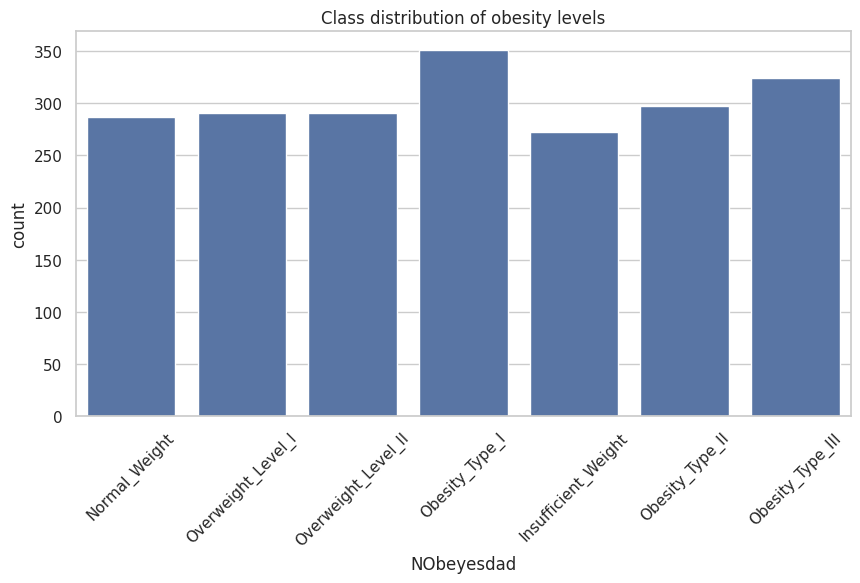

In [11]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity=pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(data=obesity,x="NObeyesdad")
plt.xticks(rotation=45)
plt.title("Class distribution of obesity levels")
plt.show()


How many rows/features are there?
There are 2111 rows.
 Which columns are categorical vs numeric?
 Categorical columns are: Gender, family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS.
 Numeric columns are:Age, Height, Weight, FCVC, NCP, CH20, FAF, TUE.

  Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?
  It is not balanced across all of them, because some categories of obesity appear more than the others.IMmbalance matters because the models may become biased towards the majority classes which will lead to the poor performance in minority models.

In [15]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

encodedobesity=obesity.copy()
encodedobesity["family_history_with_overweight"]=encodedobesity["family_history_with_overweight"].map({"yes":1,"no":0})
encodedobesity["FAVC"]=encodedobesity["FAVC"].map({"yes":1,"no":0})
encodedobesity["SMOKE"]=encodedobesity["SMOKE"].map({"yes":1,"no":0})
encodedobesity["SCC"]=encodedobesity["SCC"].map({"yes":1,"no":0})
encodedobesity=pd.get_dummies(encodedobesity,columns=["Gender","MTRANS"],drop_first=True)
encodedobesity["CAEC"]=encodedobesity["CAEC"].map({"no":0,"sometimes":1,"frequently": 2,"always": 3})
encodedobesity["CALC"]=encodedobesity["CALC"].map({"no":0,"sometimes":1,"frequently":2})
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
encodedobesity["NObeyesdad"]=encoder.fit_transform(encodedobesity["NObeyesdad"])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
X = encodedobesity.drop("NObeyesdad", axis=1)
y = encodedobesity["NObeyesdad"]
from sklearn.model_selection import train_test_split
Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size=0.4, random_state=42)
Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size=0.5, random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrainscaled = scaler.fit_transform(Xtrain)
Xvalidatedscaled = scaler.transform(Xval)
Xtestscaled = scaler.transform(Xtest)


 1. How did you encode each type of categorical variable, and why?
 For the binary categorical variables, i used 0 or 1 mapping since their output results in yes or no. For the nominal variables, i used one hot encoding
2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level.
No i didnt engineer any feauture.
No it isnt fair, because including it may make predicting the task too simple, since bmi has a close relationship with obesity, as it is calculated using height and weight.
3. Which scaler did you use and why?
I used the standard scaler. because, it removes the mean and scales it to variance unit, which ensures the features contribute equally to the model.

In [19]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X=encodedobesity.drop(columns=["NObeyesdad"])
Y=encodedobesity["NObeyesdad"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split
RANDOM_STATE=42
Xtrain,Xtemp,ytrain,ytemp=train_test_split(X,y,test_size=0.4,random_state=42,stratify=y)
Xtrain,Xtemp,ytrain,ytemp=train_test_split(Xtemp,ytemp,test_size=0.5,random_state=42,stratify=ytemp)
# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xtrainscaled=scaler.fit_transform(Xtrain)
Xvalidatedscaled=scaler.transform(Xval)
XtestScaled=scaler.transform(Xtest)


What split ratio did you choose?
60% for training,20% for validating and 20% for testing
Why is stratify=y important for this dataset?
It ensures all the splits have an equal distributionof the 7 obesity classes.
What could go wrong if you split without stratifying?
The model will not learn all the classes properly since some may not appear which will in turn reduce its accuracy and reliabilty.




train accuracy: 0.8364928909952607
validated accuracy: 0.7796208530805687
test accuracy: 0.8014184397163121
train F1: 0.8303319557748102
val F1: 0.7682378641675589
test F1: 0.786213786499504


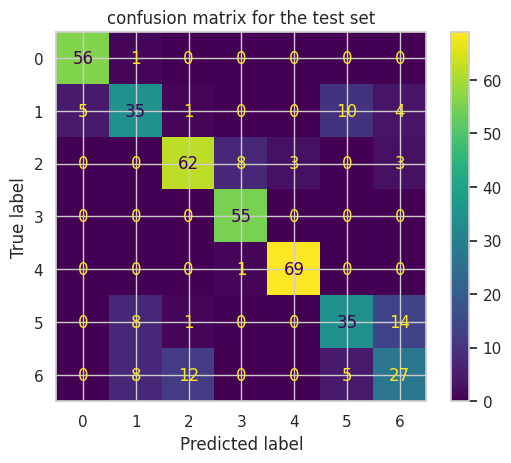

In [22]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
Xtrainscaled = np.nan_to_num(Xtrainscaled)
Xvalscaled = np.nan_to_num(Xvalscaled)
Xtestscaled = np.nan_to_num(Xtestscaled)

model=LogisticRegression(max_iter=1000)
model.fit(Xtrainscaled,ytrain)
# TODO: Predict on train, validation, and test.
predictedtrain=model.predict(Xtrainscaled)
predictedvalidation=model.predict(Xvalscaled)
predictedtest=model.predict(Xtestscaled)
# TODO: Report accuracy AND macro-F1 for ALL THREE sets
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("train accuracy:", accuracy_score(ytrain, predictedtrain))
print("validated accuracy:", accuracy_score(yval, predictedvalidation))
print("test accuracy:", accuracy_score(ytest, predictedtest))

print("train F1:", f1_score(ytrain, predictedtrain, average="macro"))
print("val F1:", f1_score(yval, predictedvalidation, average="macro"))
print("test F1:", f1_score(ytest, predictedtest, average="macro"))
# TODO: Show a confusion matrix for the test set
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(ytest, predictedtest)
plt.title("confusion matrix for the test set")
plt.show()
#   Which classes are most often confused?

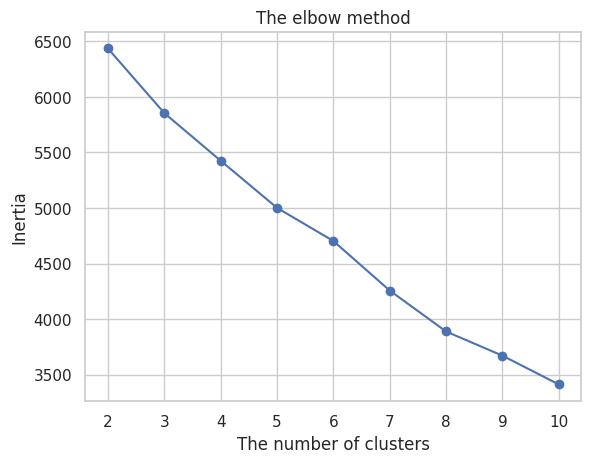

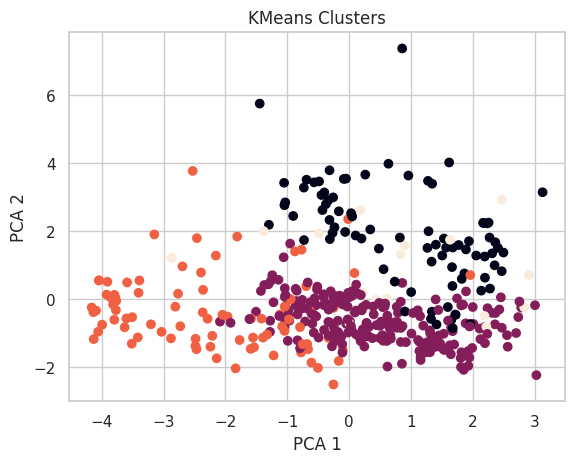

In [34]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
XCluster=Xtrainscaled
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertia=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(XCluster)
  inertia.append(kmeans.inertia_)
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("The number of clusters")
plt.ylabel("Inertia")
plt.title("The elbow method")
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
k=4
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
clusters=kmeans.fit_predict(XCluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X2d=pca.fit_transform(XCluster)
plt.scatter(X2d[:, 0], X2d[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters")
plt.show()


In [31]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
import pandas as pd

pd.crosstab(clusters,ytrain)


NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,17,13,34,53,1,16,35
1,7,9,32,5,64,20,15
2,0,1,2,0,0,1,1
3,30,24,0,0,0,17,7
4,1,10,2,1,0,4,0


Student Reasoning — Clustering 1. How did you choose k? Quote the Elbow/silhouette evidence.
I chose k as 5 using Elbow method. The result of the graph showed that after k was around 5 therabout, more clusters did not improve the clustering.
 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down?
 Yes in a way. For example, the cluster 1 is mostly made up of class 4, and cluster 0 is mostly made of classes 2, 3 and 6. This emphasizes that although k means chan identify groups, it does not accurately separate the various categories.

 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?
 The clusters will be used to group individuals with similar characteristics, and it will be useful in health education, and screening.

REFLECTIONS
nswer in a few sentences each:

1. Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
It learnt how to predict the obesity level since the categories of obesity were use din training it. On the other hand, Kmeans rather categorise dthem based on similarities and not labels, which helpes show certain common patterns that could not be seen initially.
2. Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Regression was evaluated using RMSE AND R squared, since regression gives a continious value. Classification gives categories, so we used accuracy and macro f1 to check how well th emodel did the classifictations.
3. Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
I saw the biggest train vs test gap under regression. To close it, i will change the hyperparameters of the model so it would be able to perform better and generalise on unseen data.